# Reverse Stock Split Shorting Strategy - Quantitative Analysis & Timing EDA
## Phase 1 & 2: Database Ingestion, Pristine Reconstruction, & Notice-Period Backtest

**Objective**: This notebook presents the exploratory data analysis (EDA) and backtest of a short-selling strategy targeting companies announcing reverse stock splits. By rebuilding a pristine historical EDGAR announcements database using a hybrid Regex + LLM pipeline, we solve the historical 96.4% false-positive noise rate and perform a precise notice-period timing and holding-period return analysis using Yahoo Finance (`yfinance`) pricing.

### 1. Environment Setup & Core Dependencies
We start by importing our libraries, adding our `src` path, and connecting to our MongoDB Atlas database collections.

In [7]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add src path for database access
sys.path.append(str(Path('../src')))
from split_strategy.database import get_collection, REVERSE_SPLITS_COLLECTION, EDGAR_COLLECTION
from split_strategy.edgar.scoring import parse_sa_ratio
from split_strategy.edgar.utils import parse_date

print("Environment initialized. Core modules imported successfully.")

Environment initialized. Core modules imported successfully.


In [ ]:
import pandas as pd
from split_strategy.database import get_collection, REVERSE_SPLITS_COLLECTION

splits_coll = get_collection(REVERSE_SPLITS_COLLECTION)
df_dates = pd.DataFrame(list(splits_coll.find({}, {"Date": 1})))
df_dates['parsed'] = pd.to_datetime(df_dates['Date'], errors='coerce')

print(f"Data Coverage Starts: {df_dates['parsed'].min().strftime('%Y-%m-%d')}")
print(f"Data Coverage Ends:   {df_dates['parsed'].max().strftime('%Y-%m-%d')}")

Data Coverage Starts: 2024-11-15
Data Coverage Ends:   2026-06-12


### 2. Reconstructed Database Ingestion & Coverage Report
Let's load the data from MongoDB and analyze our database coverage. Our reconstruction pipeline has successfully rebuilt the `reverse_splits_edgar` collection, ensuring that each split event maps to genuine SEC split filing announcements.

In [8]:
reverse_coll = get_collection(REVERSE_SPLITS_COLLECTION)
edgar_coll = get_collection(EDGAR_COLLECTION)

splits = list(reverse_coll.find({}))
edgar_filings = list(edgar_coll.find({}))

df_splits = pd.DataFrame(splits)
df_filings = pd.DataFrame(edgar_filings)

df_splits['_id'] = df_splits['_id'].astype(str)
df_splits['parsed_split_date'] = df_splits['Date'].apply(parse_date)
df_splits['split_date_obj'] = pd.to_datetime(df_splits['parsed_split_date'], errors='coerce')
df_splits['sa_ratio'] = df_splits['Split Ratio'].apply(parse_sa_ratio)

print(f"Loaded {len(df_splits)} historical completed splits from '{REVERSE_SPLITS_COLLECTION}'.")
if not df_filings.empty:
    df_filings['reverse_splits_id'] = df_filings['reverse_splits_id'].astype(str)
    df_filings['filing_date_obj'] = pd.to_datetime(df_filings['filing_date'], errors='coerce')
    print(f"Loaded {len(df_filings)} confirmed high-fidelity filings from '{EDGAR_COLLECTION}'.")
else:
    print("Warning: EDGAR filings database is empty. Please run reconstruction script first.")

Loaded 951 historical completed splits from 'reverse_splits'.
Loaded 4285 confirmed high-fidelity filings from 'reverse_splits_edgar'.


### 3. Lead Time Analysis (Notice Window $T_{split} - T_{ann}$)
Grouping matched filings per split event enables us to identify the **absolute earliest notice date ($T_{ann}$)**. We calculate the lead time in days and categorize splits into notice-period windows.

In [9]:
if not df_filings.empty:
    # 1. DEFINITIVE ANNOUNCEMENTS (Current Reports: 8-K, 6-K | Tier A or B)
    # These represent the board's official decision to execute the split.
    def_forms = ['8-K', '6-K', '8-K/A', '6-K/A']
    df_def = df_filings[df_filings['form'].isin(def_forms) & df_filings['tier'].isin(['A', 'B'])].copy()
    
    # Group by split event and get the earliest definitive notice date
    earliest_def_idx = df_def.groupby('reverse_splits_id')['filing_date_obj'].idxmin()
    df_earliest_def = df_def.loc[earliest_def_idx].copy()
    
    df_merged_def = pd.merge(df_splits, df_earliest_def, left_on='_id', right_on='reverse_splits_id', suffixes=('_split', '_filing'))
    df_merged_def['lead_time'] = (df_merged_def['split_date_obj'] - df_merged_def['filing_date_obj']).dt.days
    
    print("==================================================")
    print("      DEFINITIVE ANNOUNCEMENTS (8-K / 6-K, A/B)   ")
    print("==================================================")
    print(f"  Mean Notice Window:   {df_merged_def['lead_time'].mean():.1f} days")
    print(f"  Median Notice Window: {df_merged_def['lead_time'].median():.1f} days (Real Actionable Entry Date)")
    print(f"  Min Notice Window:    {df_merged_def['lead_time'].min():.1f} days")
    print(f"  Max Notice Window:    {df_merged_def['lead_time'].max():.1f} days")
    
    # Categories
    df_merged_def['Lead_Time_Cat'] = pd.cut(
        df_merged_def['lead_time'], 
        bins=[-999, -1, 2, 10, 30, 9999], 
        labels=['Negative (Post-split)', 'Very Short (0-2d)', 'Short (3-10d)', 'Standard (11-30d)', 'Long (>30d)']
    )
    print("\nLead Time Distribution:")
    print(df_merged_def['Lead_Time_Cat'].value_counts().sort_index())
    
    # 2. BOARD PROPOSALS (Proxies: DEF 14A, PRE 14A, etc.)
    # These represent seeking discretionary voting authority.
    prop_forms = ['PRE 14A', 'DEF 14A', 'DEFA14A', 'PRE 14C', '14C']
    df_prop = df_filings[df_filings['form'].isin(prop_forms)].copy()
    
    if not df_prop.empty:
        earliest_prop_idx = df_prop.groupby('reverse_splits_id')['filing_date_obj'].idxmin()
        df_earliest_prop = df_prop.loc[earliest_prop_idx].copy()
        
        df_merged_prop = pd.merge(df_splits, df_earliest_prop, left_on='_id', right_on='reverse_splits_id', suffixes=('_split', '_filing'))
        df_merged_prop['lead_time'] = (df_merged_prop['split_date_obj'] - df_merged_prop['filing_date_obj']).dt.days
        
        print("\n==================================================")
        print("        BOARD PROPOSALS (DEF 14A / PRE 14A)       ")
        print("==================================================")
        print(f"  Mean Proposal Window:   {df_merged_prop['lead_time'].mean():.1f} days")
        print(f"  Median Proposal Window: {df_merged_prop['lead_time'].median():.1f} days (Vague Proxy Discussion)")
        print(f"  Min Proposal Window:    {df_merged_prop['lead_time'].min():.1f} days")
        print(f"  Max Proposal Window:    {df_merged_prop['lead_time'].max():.1f} days")
        
    # 3. UNFILTERED HISTORICAL MAPPING (All keyword hits - S-3 registrations, early drafts)
    earliest_any_idx = df_filings.groupby('reverse_splits_id')['filing_date_obj'].idxmin()
    df_earliest_any = df_filings.loc[earliest_any_idx].copy()
    df_merged_any = pd.merge(df_splits, df_earliest_any, left_on='_id', right_on='reverse_splits_id', suffixes=('_split', '_filing'))
    df_merged_any['lead_time'] = (df_merged_any['split_date_obj'] - df_merged_any['filing_date_obj']).dt.days
    
    print("\n==================================================")
    print("      UNFILTERED FIRST PUBLIC MENTION (130d)      ")
    print("==================================================")
    print(f"  Mean Unfiltered Window:   {df_merged_any['lead_time'].mean():.1f} days")
    print(f"  Median Unfiltered Window: {df_merged_any['lead_time'].median():.1f} days (Noisy Baseline)")
    
else:
    print("No filings available to analyze lead times.")

      DEFINITIVE ANNOUNCEMENTS (8-K / 6-K, A/B)   
  Mean Notice Window:   34.1 days
  Median Notice Window: 6.0 days (Real Actionable Entry Date)
  Min Notice Window:    -14.0 days
  Max Notice Window:    179.0 days

Lead Time Distribution:
Lead_Time_Cat
Negative (Post-split)     40
Very Short (0-2d)        102
Short (3-10d)            217
Standard (11-30d)         93
Long (>30d)              168
Name: count, dtype: int64

        BOARD PROPOSALS (DEF 14A / PRE 14A)       
  Mean Proposal Window:   88.1 days
  Median Proposal Window: 76.0 days (Vague Proxy Discussion)
  Min Proposal Window:    -14.0 days
  Max Proposal Window:    180.0 days

      UNFILTERED FIRST PUBLIC MENTION (130d)      
  Mean Unfiltered Window:   111.7 days
  Median Unfiltered Window: 130.0 days (Noisy Baseline)


### 4. Definitive Announcement Notice Period Distribution
Let's display the lead time plot generated by our timing script, focusing on the critical 0 to 30 day warning window.

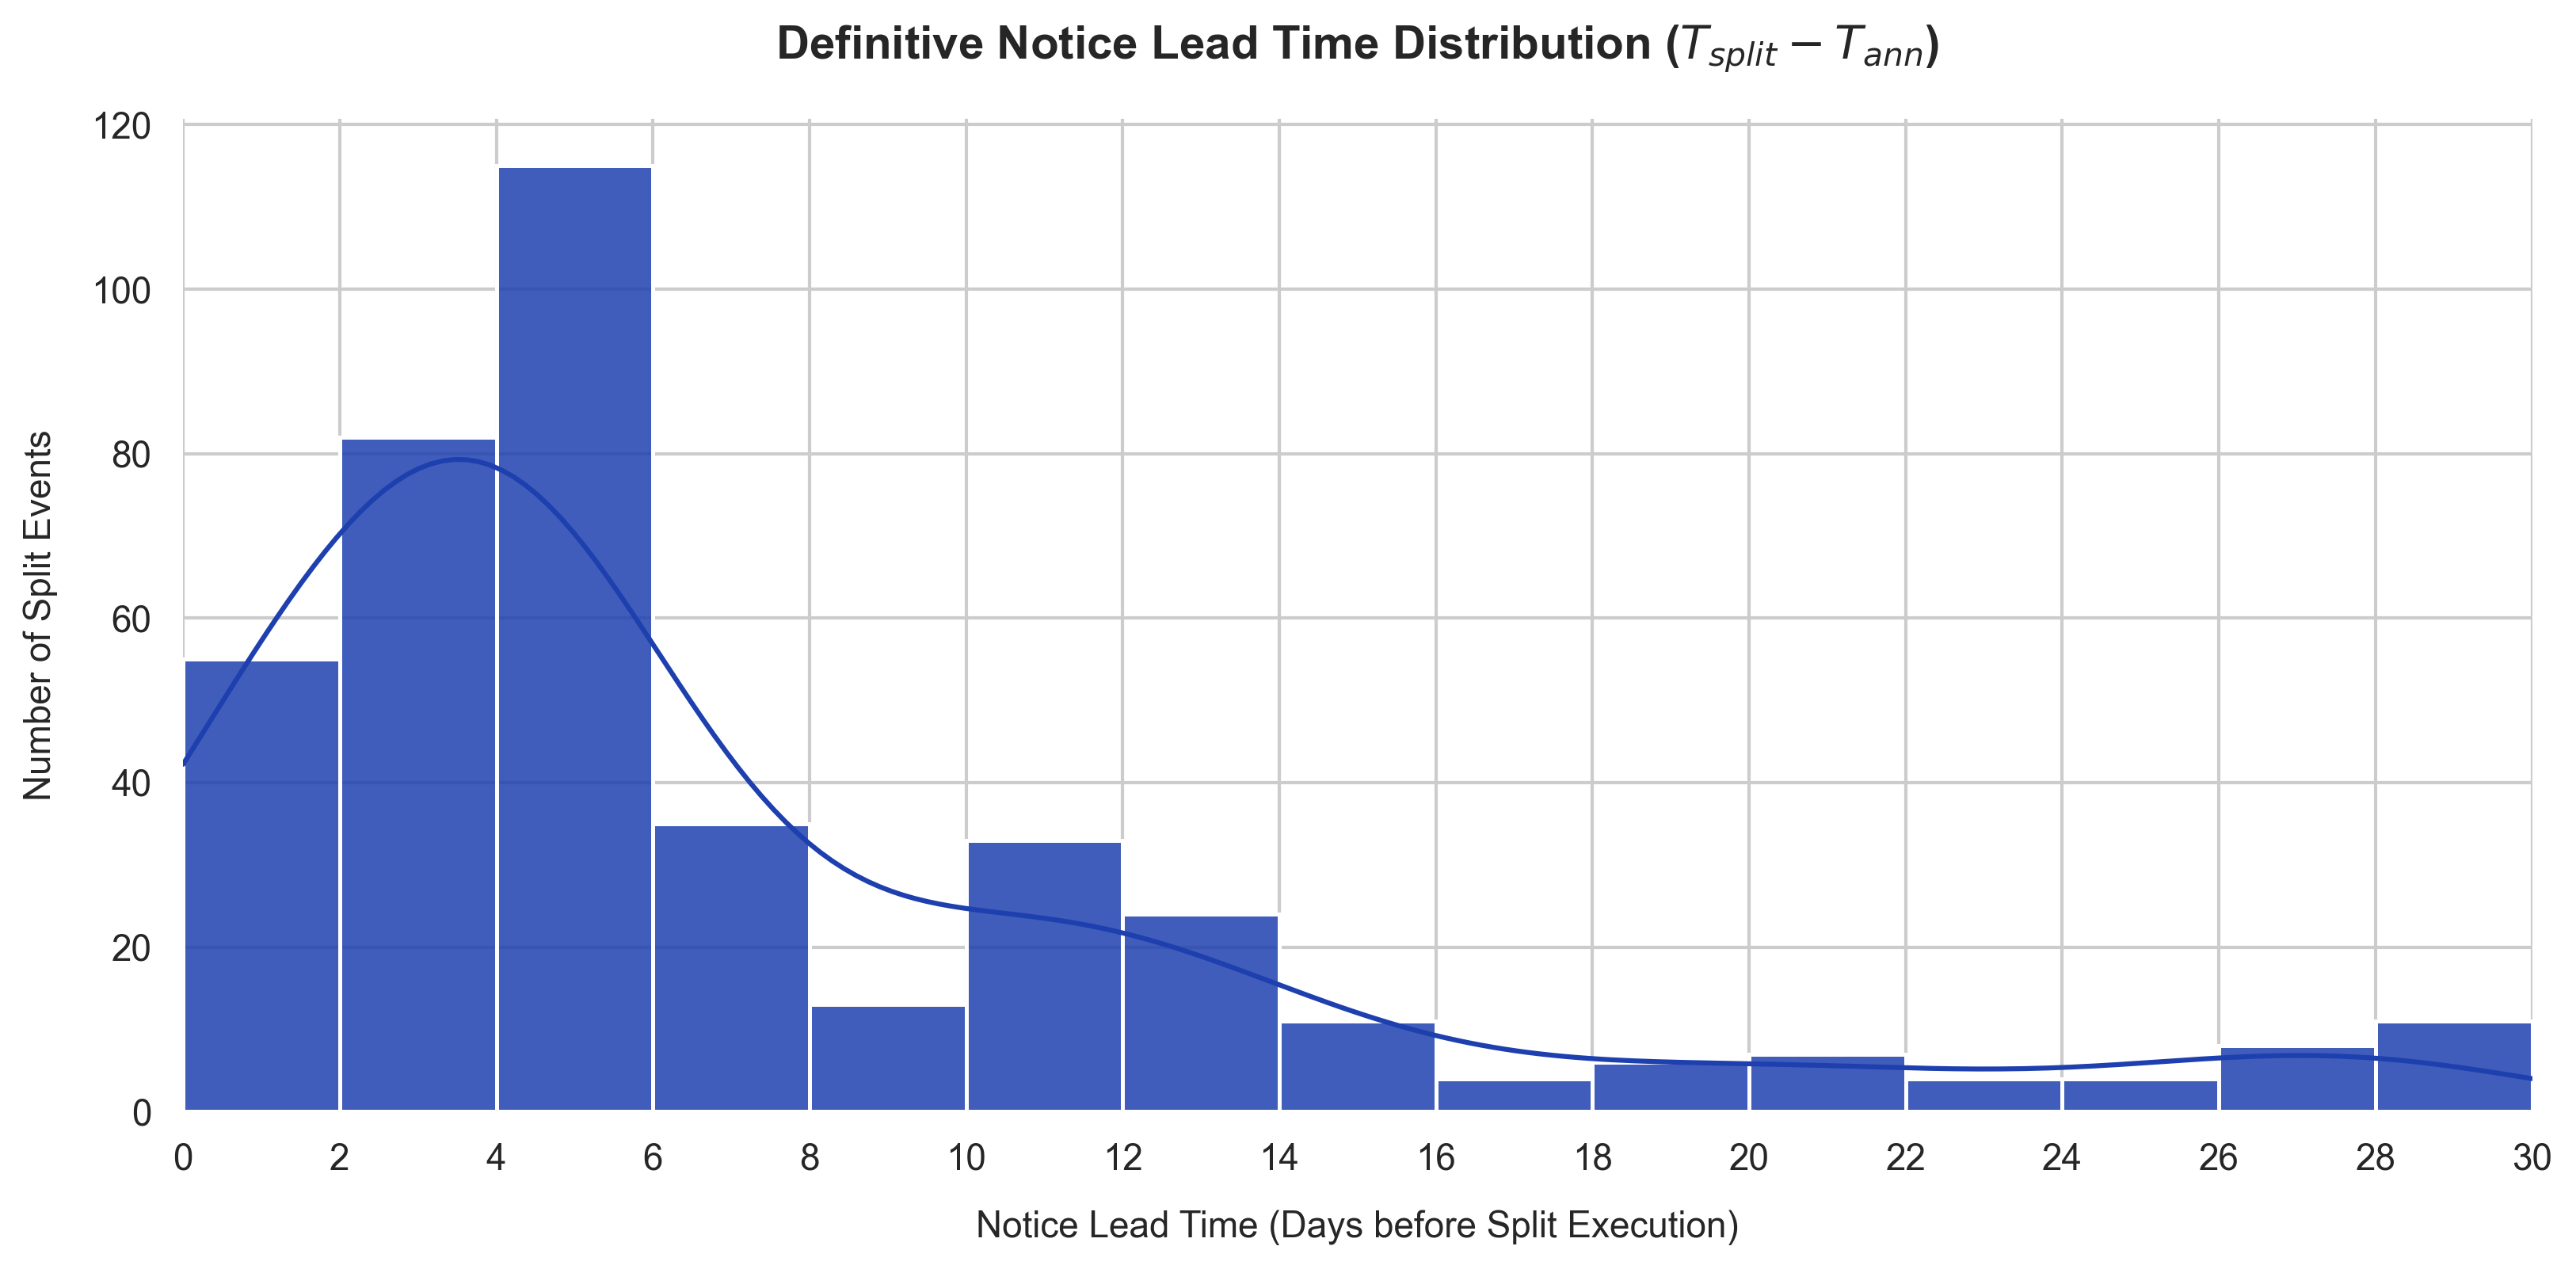

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

if not df_filings.empty:
    # Filter definitive execution filings
    def_forms = ['8-K', '6-K', '8-K/A', '6-K/A']
    df_def = df_filings[df_filings['form'].isin(def_forms) & df_filings['tier'].isin(['A', 'B'])].copy()
    
    earliest_def_idx = df_def.groupby('reverse_splits_id')['filing_date_obj'].idxmin()
    df_earliest_def = df_def.loc[earliest_def_idx].copy()
    
    df_merged_def = pd.merge(df_splits, df_earliest_def, left_on='_id', right_on='reverse_splits_id', suffixes=('_split', '_filing'))
    df_merged_def['lead_time'] = (df_merged_def['split_date_obj'] - df_merged_def['filing_date_obj']).dt.days
    
    # Focus on the definitive notice period (0 to 30 days before split execution)
    df_plot = df_merged_def[(df_merged_def['lead_time'] >= 0) & (df_merged_def['lead_time'] <= 30)].copy()
    
    # Set premium, high-resolution style
    plt.figure(figsize=(11, 5.5), dpi=300)
    sns.set_theme(style="whitegrid")
    
    # Create distribution histogram with KDE
    ax = sns.histplot(
        data=df_plot,
        x="lead_time",
        bins=15,
        kde=True,
        color="#1e40af",      # Premium corporate deep blue
        edgecolor="white",
        linewidth=1.2,
        alpha=0.85
    )
    
    # Custom styling
    plt.title("Definitive Notice Lead Time Distribution ($T_{split} - T_{ann}$)", fontsize=14, fontweight='bold', pad=18)
    plt.xlabel("Notice Lead Time (Days before Split Execution)", fontsize=11, labelpad=10)
    plt.ylabel("Number of Split Events", fontsize=11, labelpad=10)
    
    # Grid/spines alignment
    sns.despine(left=True, bottom=True)
    plt.xlim(0, 30)
    plt.xticks(range(0, 31, 2))
    plt.tight_layout()
    plt.show()
else:
    print("No filings available to plot.")